# import lightgbm as lgb
XGBoost：
  樹是一層一層往下長（Level-wise）
  每層所有節點都要計算
  資料大時很慢

LightGBM：
  樹是找最有價值的葉子優先長（Leaf-wise）
  跳過不重要的節點
  速度快很多

速度XGB：
  資料小 → 差不多
  資料大（100萬筆以上）→ LightGBM 快很多

競賽選擇：
  時間充裕 → 兩個都試，取較好的
  時間緊   → 直接用 LightGBM

  # 建立 LightGBM 分類模型
model = lgb.LGBMClassifier(

    # 不顯示訓練訊息
    verbose=-1,

    # 最多建立 1000 棵樹
    n_estimators=1000,

    # 學習率(每棵樹的貢獻程度)
    learning_rate=0.01
)


# warning
LightGBM 訓練時用的是 DataFrame（有欄位名稱）
但預測時丟進去的是 numpy array（沒有欄位名稱）

In [5]:
import numpy as ny
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X,y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

import pandas as pd

X_train_df = pd.DataFrame(X_train)
X_test_df = pd.DataFrame(X_test)

#model = lgb.LGBMClassifier()

model = lgb.LGBMClassifier(verbose=-1, n_estimators=1000, learning_rate=0.01)

eval_set=[(X_test_df, y_test)]
callbacks=[lgb.early_stopping(20), lgb.log_evaluation(50)]
model.fit(X_train_df, y_train, eval_set=eval_set, callbacks=callbacks)
y_pred = model.predict(X_test_df)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Training until validation scores don't improve for 20 rounds
[50]	valid_0's binary_logloss: 0.4753
[100]	valid_0's binary_logloss: 0.377396
[150]	valid_0's binary_logloss: 0.333502
[200]	valid_0's binary_logloss: 0.313202
[250]	valid_0's binary_logloss: 0.302662
[300]	valid_0's binary_logloss: 0.298795
Early stopping, best iteration is:
[310]	valid_0's binary_logloss: 0.298152
Accuracy: 0.90


c:\Users\light\competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\light\competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24501 (\N{CJK UNIFIED IDEOGRAPH-5FB5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\light\competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\light\competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\light\competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAP

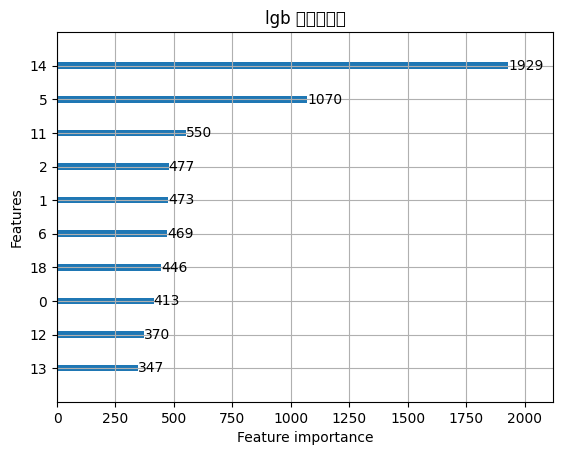

In [6]:
lgb.plot_importance(model, max_num_features=10)
plt.title('lgb 特徵重要性')
plt.show()